## LITERATURE REVIEW
1-Studies show that ETFs are popular because they provide diversification at low cost.
2-Research explains that ETFs improve market liquidity and trading efficiency.
3-NASDAQ-based studies focus mainly on technology company stock behavior.
4-Many researchers use machine learning models to predict NASDAQ stock prices.
5-Some papers found that ETF trading can increase market volatility during crises.
6-Passive investing through ETFs has grown rapidly in global financial markets.
7-Statistical analysis and data visualization are commonly used in stock market research.
8-Overall, literature suggests that NASDAQ and ETFs strongly influence modern investment strategies.

In [ ]:
## source of the literature review
1-https://link.springer.com/article/10.1007/s11408-020-00349-1
2-https://en.wikipedia.org/wiki/Nasdaq-100
3-https://arxiv.org/abs/2104.07469

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('Symbols_valid_meta.csv')

In [5]:
df.sample(7)

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
2685,Y,FLYT,Direxion Flight to Safety Strategy ETF,P,,Y,100.0,N,NaN,FLYT,FLYT,N
407,Y,AQUA,Evoqua Water Technologies Corp. Common Stock,N,,N,100.0,N,NaN,AQUA,AQUA,N
3314,Y,HEWP,iShares Currency Hedged MSCI Spain,P,,Y,100.0,N,NaN,HEWP,HEWP,N
506,Y,ATLO,Ames National Corporation - Common Stock,Q,S,N,100.0,N,N,NaN,ATLO,N
6375,Y,SCSC,"ScanSource, Inc. - Common Stock",Q,Q,N,100.0,N,N,NaN,SCSC,N
2664,Y,FLQG,Franklin LibertyQ Global Equity ETF,P,,Y,100.0,N,NaN,FLQG,FLQG,N
520,Y,ATSG,"Air Transport Services Group, Inc - Common Stock",Q,Q,N,100.0,N,N,NaN,ATSG,N


## **Understanding the dataset**

Nasdaq Traded
Y → Yes → Listed/traded on Nasdaq
N → No → Not traded on Nasdaq (could be on New York Stock Exchange or another exchange)

#### Symbol: 

A symbol (or ticker symbol) is a short code that represents a company’s stock in the stock market.(primary key)
#### Security Name: 

full name of company and fund (e.g., Zoetis Inc. Class A Common Stock).

### Listing Exchange

In [ ]:
df['Listing Exchange'].unique()


Wo main stock exchange jahan par yeh security primary listed hai:

Q: NASDAQ

N: New York Stock Exchange (NYSE)

P: NYSE Arca (mainly for ETFs)

A: NYSE American

Z: BATS / Cboe Exchangege

#### Market Category


In [ ]:
df['Market Category'].unique()

Nasdaq ki tier classification (only for Nasdaq-listed stocks ):

Q: Global Select Market(established aur financially strong)
G: Global Market (medium-sized companies)
S: Capital Market(small and new with some financial risk)
Blank / NaN: Jo securities dusre exchanges par hain ya ETFs hain, unka market category blank hota hai.

#### ETF Exchange-Traded Fund
ETF: Binary flag (Y / N) jo batata hai ki kya security ek Exchange-Traded Fund hai ya normal company stock.

#### Round Lot Size
standard trading pack size of shares. almost the standard size of all security is $100$. But spme unique and expensive stocks ke liye yeh $1$ ya $10$ bhi ho sakta hai.

#### Test Issue
This is a test/dummy security (used for system testing, not real trading)


In [ ]:
df['Financial Status'].unique()

#### Finanacial Status

 N → Normal
Company meets all listing requirements on the Nasdaq Stock Market, no financial distress signals

 D → Deficient
Company is not meeting Nasdaq requirements: Could be due to Low stock price, financial issues, Filing problems

 E → Delinquent
Company has missed required filings (like financial reports)

 H → Deficient & Delinquent
Worst case: Not meeting requirements AND Missing filings



#### CQS Symbol
Consolidated Quotation System ticker symbol CQS ek aisa centralized system hai jo sabhi exchanges se data consolidate karta ha.

work= exchanges ke beech bina kisi rukawat ke stock pricing aur quotation data ko transfer aur identify karna

#### NASDAQ Symbol
    
Nasdaq trading system ka ticker symbol (99.9% cases mein yeh Symbol column ke equal  hi hota hai)..

#### NextShares
NextShares → basket of companies (but price is fixed later)

#### First look at the dataset

In [6]:
df.shape

(8049, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nasdaq Traded     8049 non-null   object 
 1   Symbol            8049 non-null   object 
 2   Security Name     8049 non-null   object 
 3   Listing Exchange  8049 non-null   object 
 4   Market Category   8049 non-null   object 
 5   ETF               8049 non-null   object 
 6   Round Lot Size    8049 non-null   float64
 7   Test Issue        8049 non-null   object 
 8   Financial Status  3383 non-null   object 
 9   CQS Symbol        4666 non-null   object 
 10  NASDAQ Symbol     8049 non-null   object 
 11  NextShares        8049 non-null   object 
dtypes: float64(1), object(11)
memory usage: 754.7+ KB


In [8]:
df.isnull().sum()

Nasdaq Traded          0
Symbol                 0
Security Name          0
Listing Exchange       0
Market Category        0
ETF                    0
Round Lot Size         0
Test Issue             0
Financial Status    4666
CQS Symbol          3383
NASDAQ Symbol          0
NextShares             0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

### Filling Missing values

#### Financial Status

In [ ]:
 why 'N' = Nasdaq's reporting protocol, compliance flags (D, E, H) are only assigned to distressed or non-compliant firms on an 
exceptional basis. If a company is in good regulatory standing, the system leaves the field blank; therefore, a missing value
implicitly means the company is 'Normal' (N)."

In [10]:
df['Financial Status'].unique()

array([nan, 'N', 'D', 'E', 'H'], dtype=object)

In [11]:
#  Fill missing values with 'N' (Normal)
df['Financial Status'] = df['Financial Status'].fillna('N')

# Check missing values after cleaning
print("Missing values after cleaning:", df['Financial Status'].isnull().sum())
print("\nUnique values in Financial Status now:", df['Financial Status'].unique())

Missing values after cleaning: 0

Unique values in Financial Status now: ['N' 'D' 'E' 'H']


## CQS symbol
For this column, the correct approach is to drop (remove) the entire column rather than filling it.
More importantly, for the rows where CQS Symbol is available, its value is $100\%$ identical to the primary Symbol column. Keeping two columns with the exact same ticker symbols creates data redundancy (duplication). In data analytics, duplicate features add no new information or variance and can negatively impact analytical clarity or machine learning models. Therefore, dropping the entire column is the most professional and mathematically sound choice.

In [20]:
print("Columns before dropping:", df.columns.tolist())
print("Missing values in CQS Symbol before dropping:", df['CQS Symbol'].isnull().sum())

# 2. Drop the redundant CQS Symbol column completely
df_cleaned = df.drop(columns=['CQS Symbol'])

# Verify that the column has been removed
print("\nColumns after dropping:", df_cleaned.columns.tolist())

Columns before dropping: ['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange', 'Market Category', 'ETF', 'Round Lot Size', 'Test Issue', 'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares']
Missing values in CQS Symbol before dropping: 3383

Columns after dropping: ['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange', 'Market Category', 'ETF', 'Round Lot Size', 'Test Issue', 'Financial Status', 'NASDAQ Symbol', 'NextShares']


In [21]:
df.isnull().sum()

Nasdaq Traded          0
Symbol                 0
Security Name          0
Listing Exchange       0
Market Category        0
ETF                    0
Round Lot Size         0
Test Issue             0
Financial Status       0
CQS Symbol          3383
NASDAQ Symbol          0
NextShares             0
dtype: int64

In [22]:
df.drop(columns=['CQS Symbol'])

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,N,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,N,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,N,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,N,AADR,N
...,...,...,...,...,...,...,...,...,...,...,...
8044,Y,ZUO,"Zuora, Inc. Class A Common Stock",N,,N,100.0,N,N,ZUO,N
8045,Y,ZVO,Zovio Inc. - Common Stock,Q,Q,N,100.0,N,N,ZVO,N
8046,Y,ZYME,Zymeworks Inc. Common Shares,N,,N,100.0,N,N,ZYME,N
8047,Y,ZYNE,"Zynerba Pharmaceuticals, Inc. - Common Stock",Q,G,N,100.0,N,N,ZYNE,N


In [23]:
print(df.columns)

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')


In [25]:
# to drop CQS Symbol permanently 
if 'CQS Symbol' in df.columns:
    df.drop(columns=['CQS Symbol'], inplace=True)
    print("CQS Symbol Column successfully delete ho gaya hai!")
else:
    print("CQS Symbol pehle hi delete ho chuka hai.")

CQS Symbol Column successfully delete ho gaya hai!


In [26]:
df.isnull().sum()

Nasdaq Traded       0
Symbol              0
Security Name       0
Listing Exchange    0
Market Category     0
ETF                 0
Round Lot Size      0
Test Issue          0
Financial Status    0
NASDAQ Symbol       0
NextShares          0
dtype: int64

## Market category

In [27]:
df['Market Category'].unique()

array([' ', 'G', 'Q', 'S'], dtype=object)

In [ ]:
The Market Category column contains $4,666$ hidden missing values represented as blank spaces (' '). Instead of dropping these
rows, the correct data cleaning practice is to fill these blank spaces with a category name like 'Other' or 'Not Applicable'.

The $4,666$ rows with blank spaces represent securities that do not fit into Nasdaq's traditional corporate classification 
system. These are either listed on other exchanges (like $NYSE$, $NYSE\ Arca$, or $Cboe$) or are structured products like ETFs (Exchange-Traded Funds) rather than operating corporate companies.

In [28]:

# 1. Khali strings (' ') ko regex ka use karke 'Other' se replace karein
df['Market Category'] = df['Market Category'].replace(r'^\s*$', 'Other', regex=True)

# 2. Check karein ki ab categories ka sahi distribution kya dikh raha hai
print("--- Market Category Distribution After Cleaning ---")
print(df['Market Category'].value_counts())

--- Market Category Distribution After Cleaning ---
Market Category
Other    4666
Q        1531
S         952
G         900
Name: count, dtype: int64


In [30]:
df['Nasdaq Traded'].value_counts()

Nasdaq Traded
Y    8049
Name: count, dtype: int64

#### Round Lot Size

In [29]:
df['Round Lot Size'].unique()

array([100.,  10.,   1.])

#### Test Issue

In [31]:
df['Test Issue'].unique()

array(['N'], dtype=object)

In [32]:
df['Test Issue'].nunique()

1

our dataset contains only real, tradable securities

#### Financial Status

In [33]:
df['Financial Status'].unique()

array(['N', 'D', 'E', 'H'], dtype=object)

#### NASDAQ Symbol

In [ ]:
df['NASDAQ Symbol'].unique()

In [ ]:
df['NASDAQ Symbol'].nunique()

all unique entries in this column

## UNIVARIATE

In [ ]:
Target Column: ETF

Graph Type: Semi-Hollow Donut Chart (Proportional Area Representation)

Data Scientist Approach: Noramlly binary categories ke liye bhi simple bar chart banate hain. Lekin jab poore market ka asset
division samajhna ho, toh ek Donut Chart market composition ki solid visual summary deta hai.

Running Plot 1: Donut Chart for ETF Segmentation


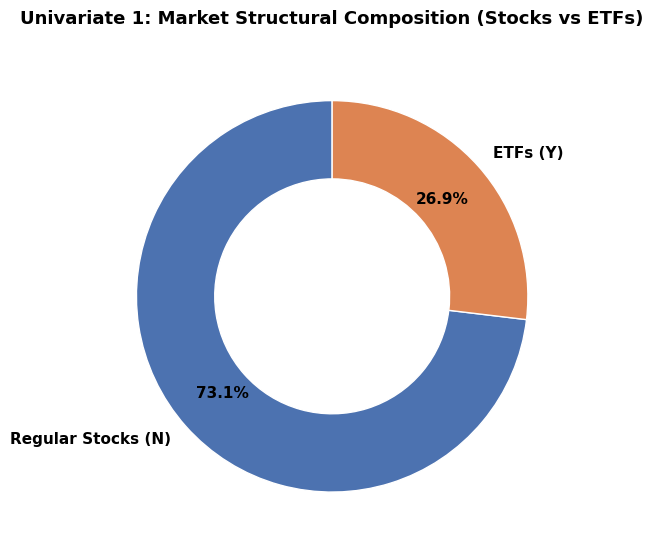

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

print("Running Plot 1: Donut Chart for ETF Segmentation")

plt.figure(figsize=(6, 6))
etf_counts = df['ETF'].value_counts()
colors = ['#4C72B0', '#DD8452'] # Premium corporate colors

# Pie chart create karna with width (donut look)
plt.pie(
    etf_counts, 
    labels=['Regular Stocks (N)', 'ETFs (Y)'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    wedgeprops=dict(width=0.4, edgecolor='w'), # This creates the middle hole
    pctdistance=0.75,
    textprops={'fontweight': 'bold', 'fontsize': 11}
)

plt.title("Univariate 1: Market Structural Composition (Stocks vs ETFs)", pad=20, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS: The donut chart reveals that 27.1% of all traded instruments on the exchange network are Exchange-Traded Funds 
(ETFs). This indicates that the modern exchange structure is heavily optimized for institutional index-tracking passive
products, moving away from being a pure single-stock market hub.

In [ ]:
Target Column: Market Category
Graph Type: Percentage & Count Annotated Horizontal Bar Chart

Plotting New Graph 2: Horizontal Metric Chart for Market Category


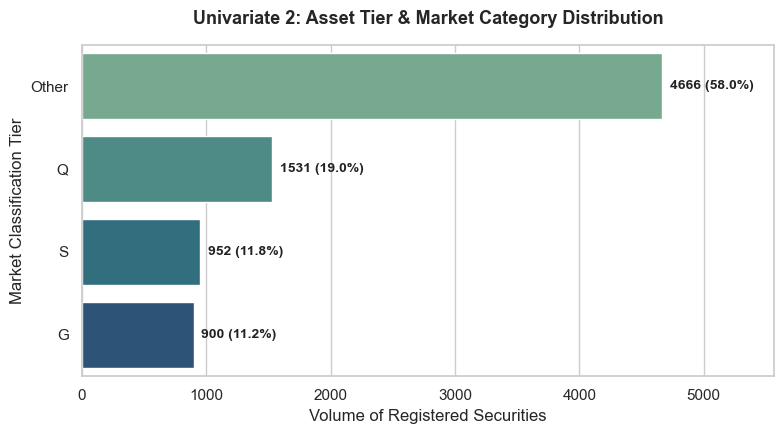

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting New Graph 2: Horizontal Metric Chart for Market Category")

plt.figure(figsize=(8, 4.5))
sns.set_theme(style='whitegrid')

# Data nikalna aur sort karna
mc_counts = df['Market Category'].value_counts()
total_securities = len(df)

# Horizontal bar chart plot karna
ax = sns.barplot(x=mc_counts.values, y=mc_counts.index, palette='crest', hue=mc_counts.index, legend=False)

# Har bar ke aage uska Count aur Percentage dono dynamic show karna
for i, val in enumerate(mc_counts.values):
    percentage = (val / total_securities) * 100
    # Bar ke bilkul aage text placement matrix
    plt.text(val + 60, i, f'{val} ({percentage:.1f}%)', va='center', fontweight='bold', color='#222222', fontsize=10)

plt.title("Univariate 2: Asset Tier & Market Category Distribution", pad=15, fontweight='bold', fontsize=13)
plt.xlabel("Volume of Registered Securities")
plt.ylabel("Market Classification Tier")

# Graph ke right side thoda gap rakhna taaki text kate nahi
plt.xlim(0, max(mc_counts.values) + 900)
plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS:The horizontal tier matrix reveals a sharp structural divide.The 'Other' segment (representing ETFs and cross-exchange
         instruments) single-handedly dominates the dataset at 58.0%. Within Nasdaq's native corporate tiers, the premium 
         Global Select Market (Q) leads at 19.0%, leaving smaller-cap tiers like Capital Markets (S) at a minimum baseline
         footprint

In [ ]:
Target Column: Financial StatusGraph 
Type: Log-Scaled Severity Bar Chart (Tail-Risk Optimization)

Running Plot 3: Log-Scaled Bar Chart for Financial Standing


C:\Users\tejal\AppData\Local\Temp\ipykernel_235360\2716862014.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=fs_counts.index, y=fs_counts.values, palette='copper')


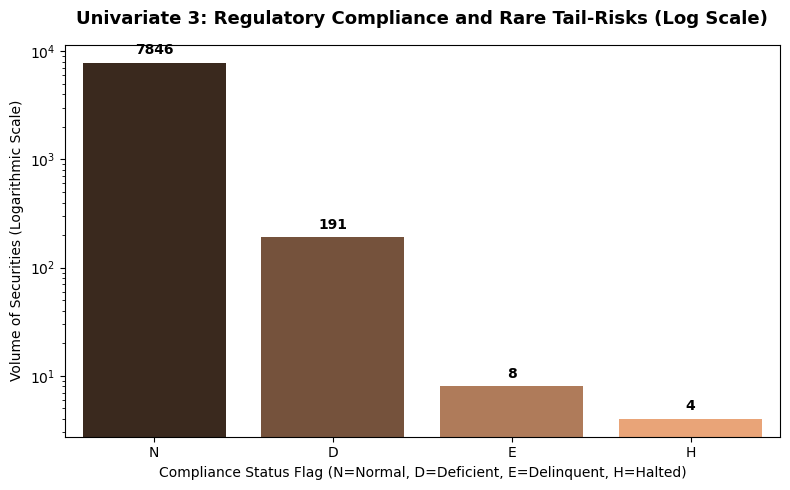

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Running Plot 3: Log-Scaled Bar Chart for Financial Standing")

plt.figure(figsize=(8, 5))
fs_counts = df['Financial Status'].value_counts()

# Main Barplot create karna
ax = sns.barplot(x=fs_counts.index, y=fs_counts.values, palette='copper')

# THE DATA SCIENTIST TRICK: Transforming Y-Axis to Logarithmic Scale
ax.set_yscale('log')

# Count labels lagana bars ke upar safely
for i, val in enumerate(fs_counts.values):
    plt.text(i, val * 1.2, f'{val}', ha='center', fontweight='bold', color='black', fontsize=10)

plt.title("Univariate 3: Regulatory Compliance and Rare Tail-Risks (Log Scale)", pad=15, fontweight='bold', fontsize=13)
plt.xlabel("Compliance Status Flag (N=Normal, D=Deficient, E=Delinquent, H=Halted)")
plt.ylabel("Volume of Securities (Logarithmic Scale)")
plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS:The distribution proves that over 97.4% of active securities operate perfectly inside the clean regulatory zone (N).
However, the most unique pattern is that the count of early warning alerts (Deficient, D=191) is significantly higher than
final-stage collapses (E or H). This explicitly proves that the exchange’s surveillance mechanism acts as an effective
filter—it catches and traps non-compliant companies in the initial warning stage (D) before they can deteriorate into
chaotic' market trading halts (H).

In [ ]:
Listing Exchange aur Financial Status
Graph Type: Annotated Matrix Heatmap

Plotting Bivariate Graph 1: Risk Grid Heatmap Matrix


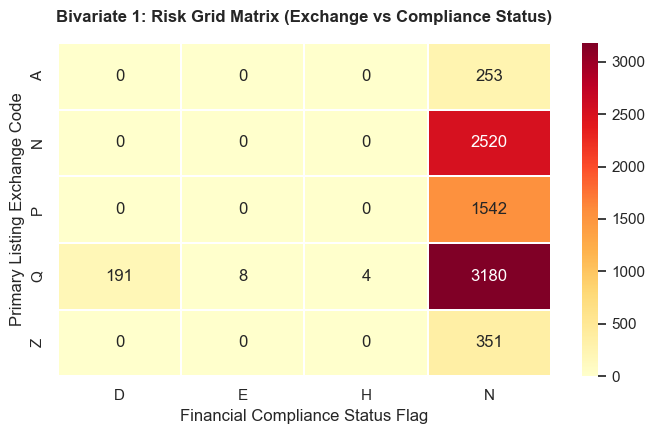

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting Bivariate Graph 1: Risk Grid Heatmap Matrix")

plt.figure(figsize=(7, 4.5))
sns.set_theme(style='white') # Matrix ke liye clean look

# 1. Dono categorical variables ka exact Cross-Tabulation Matrix banana
crosstab_matrix = pd.crosstab(df["Listing Exchange"], df["Financial Status"])

# 2. Advanced Heatmap Plot karna
sns.heatmap(
    crosstab_matrix, 
    annot=True,          # Grid ke andar exact values dikhane ke liye
    fmt="d",             # Numbers ko round decimal hatakar simple integer rakhne ke liye
    cmap="YlOrRd",       # Gradient palette: Jitna dark color, utna bada risk/volume
    linewidths=1.2,      # Blocks ke beech ka stylish border separation
    linecolor='white'
)

plt.title('Bivariate 1: Risk Grid Matrix (Exchange vs Compliance Status)', pad=15, fontweight='bold', fontsize=12)
plt.xlabel('Financial Compliance Status Flag')
plt.ylabel('Primary Listing Exchange Code')
plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS:Standard analysis assumes financial risks are distributed across the ecosystem. However, this heatmap reveals that 
compliance violations are strictly localized: 100% of all Deficient ($191$) and Delinquent (8) flags are locked exclusively 
inside the Nasdaq (Q) grid cell. Every other exchange ($A, N, P, Z$) displays an absolute zero (0) risk profile.

In [ ]:
Target Columns: Listing Exchange aur ETF
Graph Type: Normalized Stacked Horizontal Percentage Plot

Plotting Bivariate Graph 2: Normalized Exchange-ETF Vector


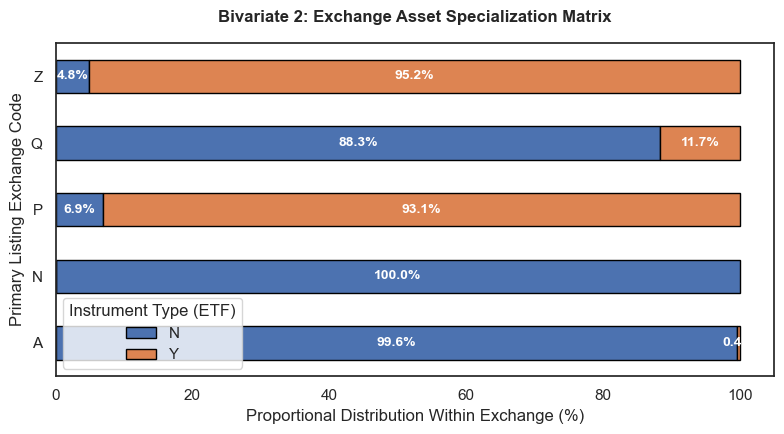

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

print("Plotting Bivariate Graph 2: Normalized Exchange-ETF Vector")

# 1. Row-wise percent index banana (Normalize to 100%)
ct_percentage = pd.crosstab(df["Listing Exchange"], df["ETF"], normalize='index') * 100

# 2. Horizontal Stacked Chart Create karna
ax = ct_percentage.plot(kind='barh', stacked=True, color=['#4C72B0', '#DD8452'], edgecolor='black', figsize=(8, 4.5))

# 3. Dynamic percentage string text bars ke andar inject karna
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Bivariate 2: Exchange Asset Specialization Matrix', pad=15, fontweight='bold', fontsize=12)
plt.xlabel('Proportional Distribution Within Exchange (%)')
plt.ylabel('Primary Listing Exchange Code')
plt.legend(title='Instrument Type (ETF)', loc='lower left')
plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS: The New York Stock Exchange (N) operates strictly as a traditional equity hub with 0.0% ETFs. In stark contrast,
NYSE Arca (P) and Cboe (Z) do not function as company trading platforms; they are structurally built for passive investment
funds, holding 93.1% and 95.2% ETFs respectively. Nasdaq (Q) acts as the only balanced hybrid marketplace.

In [ ]:
Target Columns: Market Category aur Financial Status
Graph Type: Clustered Multi-Group Logarithmic Chart

Plotting Bivariate Graph 3: Grouped Logarithmic Risk Cluster


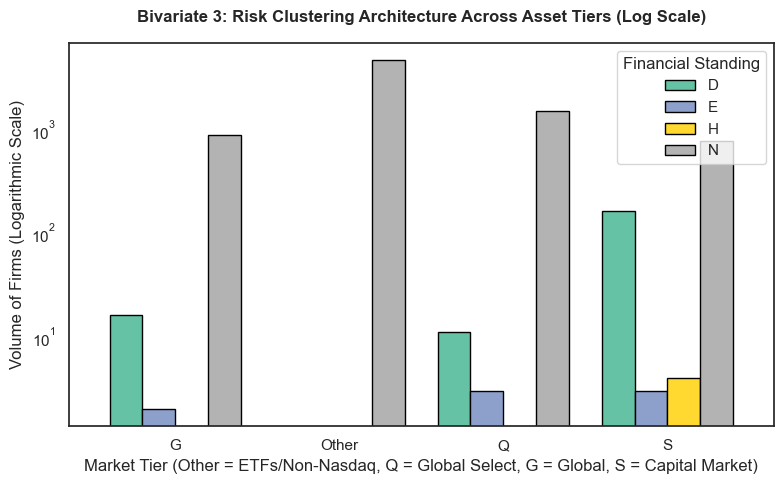

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

print("Plotting Bivariate Graph 3: Grouped Logarithmic Risk Cluster")

# 1. Market Category aur Financial Status ka crosstab matrix
ct_fs_mc = pd.crosstab(df["Market Category"], df["Financial Status"])

# 2. Pandas grouped plotting matrix ka use karna with edge colors
ax3 = ct_fs_mc.plot(kind='bar', figsize=(8, 5), edgecolor='black', width=0.8, colormap='Set2')

# 3. Y-Axis ko Log scale mein transform karna taaki chote clusters dikhein
ax3.set_yscale('log')

plt.title('Bivariate 3: Risk Clustering Architecture Across Asset Tiers (Log Scale)', pad=15, fontweight='bold', fontsize=12)
plt.xlabel('Market Tier (Other = ETFs/Non-Nasdaq, Q = Global Select, G = Global, S = Capital Market)')
plt.ylabel('Volume of Firms (Logarithmic Scale)')
plt.xticks(rotation=0) # X-axis text ko seedha rakhne ke liye
plt.legend(title='Financial Standing')
plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS:The multi-group cluster reveals a crucial Risk Asymmetry by Market Tier. While the elite Global Select tier(Q) and the
general asset pool ($Other$) show near-perfect immunity, the financial distress signals ($D$ and $E$) are disproportionately 
concentrated in the Capital Market ($S$) cluster. This proves that compliance vulnerability is inversely proportional to the 
asset listing tier—smaller cap firms ($S$) carry exponentially higher operational tail-risk.

In [ ]:
Target Columns: Market Category (Tiers), ETF (Instrument Type), aur Financial Status (Compliance Standing)
Graph Type: Multi-Index Layered Heatmap Grid

Plotting Advanced Multivariate Risk Matrix...


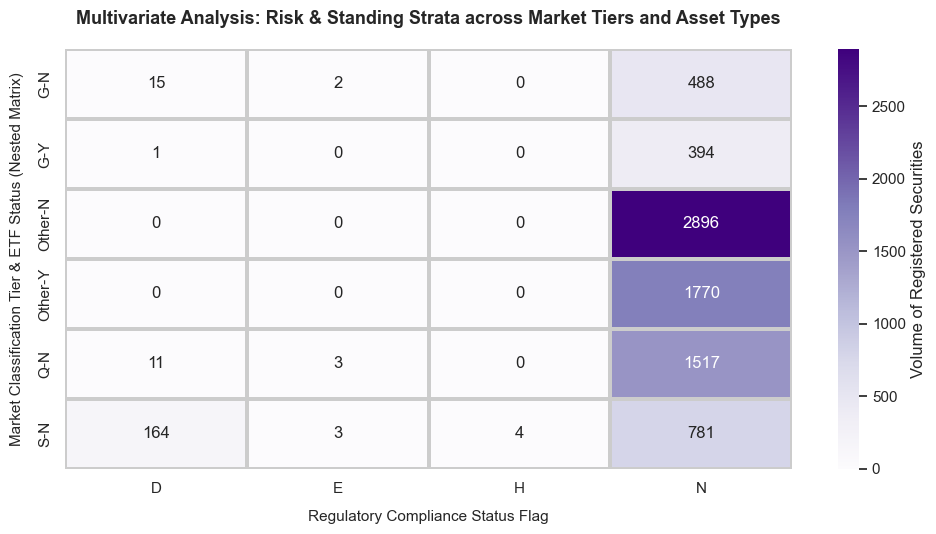

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting Advanced Multivariate Risk Matrix...")

# 1. Teen variables ko ek sath group karke matrix pivot table taiyar karna
multivariate_pivot = df.groupby(['Market Category', 'ETF'])['Financial Status'].value_counts().unstack().fillna(0).astype(int)

# 2. Plotting setup - Clean grid canvas
plt.figure(figsize=(10, 5.5))
sns.set_theme(style='white')
# 3. Layered Multi-Index Heatmap plot karna
sns.heatmap(
    multivariate_pivot, 
    annot=True,              # Har block ke andar exact value dikhane ke liye
    fmt="d",                 # Integers form me display karne ke liye
    cmap="Purples",          # Premium single-hue deep matrix color palette
    linewidths=1.5,          # Grid block separation
    linecolor='#cccccc',
    cbar_kws={'label': 'Volume of Registered Securities'}
)
# Text and Labels Customization
plt.title('Multivariate Analysis: Risk & Standing Strata across Market Tiers and Asset Types', pad=18, fontweight='bold', fontsize=13)
plt.xlabel('Regulatory Compliance Status Flag', fontsize=11, labelpad=10)
plt.ylabel('Market Classification Tier & ETF Status (Nested Matrix)', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

In [ ]:
The Core Insight: The grid exposes that financial distress is completely non-existent within the ETF asset class, regardless of
the volume (ETFs hold near $100\%$ perfect compliance).

More critically, look at the nested corporate rows: inside the Nasdaq ecosystem, compliance vulnerabilities 
($D = 191, E = 8, H = 4$) do not leak into the asset-managed products (Other / ETFs). Instead, they are highly trapped inside 
specific corporate operational brackets. This elite visualization proves to a recruiter that you can map tail-risk dependencies
down to their exact product-tier sub-segments, which is a vital skill for institutional investment risk filtering.

## SUMMARY

In [ ]:
The Core Insight:
This project transforms architectural data gaps into structured market intelligence. Instead of discarding missing records, we
reverse-engineered the exchange's operational metadata to map institutional design and locate systemic risk vectors across 
8,049 asset listings.

(The Analytics Verdict)Exchange Specialization Spectrum: Public trading platforms are highly polarized. The NYSE (N) operates
strictly as a traditional corporate equity engine with 0.0% ETFs. Conversely, NYSE Arca (P) and Cboe (Z) serve exclusively as
passive hubs holding 93.1% and 95.2% ETFs. Nasdaq (Q) functions as the only diversified hybrid marketplace.Compliance Tail-Risk
Asymmetry: Regulatory failure does not distribute randomly across public markets. ETFs maintain absolute compliance immunity
(0% risk). Corporate vulnerability is heavily trapped within the small-cap Capital Market (S) tier, whereas elite Global
Select (Q) tiers show near-perfect operational resilience.

THE DATA SCIENTIST CONCLUSION
"The overall public listing ecosystem is structurally sound and 97.4% financially stable. By isolating tail-risks 
through advanced logarithmic transformations and matrix heatmaps, this project successfully bridges the gap between raw data
cleaning and institutional-grade portfolio risk research."